In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

Below file was sourced from
https://catalog.data.gov/dataset/california-public-schools-2024-25

In [4]:
from google.colab import files
uploaded = files.upload()

Saving SchoolSites2425_5959976271030172217.csv to SchoolSites2425_5959976271030172217.csv


In [5]:
df_orig = pd.read_csv("SchoolSites2425_5959976271030172217.csv")
df_orig.head()  #Read first 5 records of a file

,OBJECTID,Academic Year,Fed ID,CDS Code,District Code,School Code,Region,County Name,District Name,School Name,...,DistrictHighCodeGeo,DistrictHighNameGeo,DistrictUnifiedCodeGeo,DistrictUnifiedNameGeo,CongUSGeo,SenateCAGeo,AssemblyCAGeo,Locale Four,x,y
0,1,2024-25,69105110947,1.100170e+12,10017,112607,4,Alameda,Alameda County Office of Education,Envision Academy for Arts & Technology,...,NaN,NaN,161259.0,Oakland Unified,12,7,18,1 - City,-13610852.27,4551869.704
1,2,2024-25,69105112844,1.100170e+12,10017,123968,4,Alameda,Alameda County Office of Education,Community School for Creative Education,...,NaN,NaN,161259.0,Oakland Unified,12,7,18,1 - City,-13607560.99,4549083.797
2,3,2024-25,69105112901,1.100170e+12,10017,124172,4,Alameda,Alameda County Office of Education,Yu Ming Charter,...,NaN,NaN,161259.0,Oakland Unified,12,7,18,1 - City,-13612383.22,4553754.734
3,4,2024-25,69105113008,1.100170e+12,10017,125567,4,Alameda,Alameda County Office of Education,Urban Montessori Charter,...,NaN,NaN,161259.0,Oakland Unified,12,7,18,1 - City,-13601904.29,4549347.479
4,5,2024-25,69105109264,1.100170e+12,10017,130401,4,Alameda,Alameda County Office of Education,Alameda County Juvenile Hall/Court,...,NaN,NaN,161309.0,San Lorenzo Unified,14,9,20,2 - Suburb,-13594139.98,4539377.261


In [6]:
#Quick sanity checks and to understand the structure of file
df_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 94 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   OBJECTID                             9982 non-null   int64  
 1   Academic Year                        9982 non-null   object 
 2   Fed ID                               9982 non-null   int64  
 3   CDS Code                             9982 non-null   float64
 4   District Code                        9982 non-null   int64  
 5   School Code                          9982 non-null   int64  
 6   Region                               9982 non-null   int64  
 7   County Name                          9982 non-null   object 
 8   District Name                        9982 non-null   object 
 9   School Name                          9982 non-null   object 
 10  School Type                          9982 non-null   object 
 11  Status                        

In [7]:
df_orig["Academic Year"].unique()  # verify how many years of data is available in the file

array(['2024-25'], dtype=object)

In [8]:
df_orig.columns.tolist() #view all the columns in the file

['OBJECTID',
 'Academic Year',
 'Fed ID',
 'CDS Code',
 'District Code',
 'School Code',
 'Region',
 'County Name',
 'District Name',
 'School Name',
 'School Type',
 'Status',
 'Open Date',
 'Closed Date',
 'School Level',
 'Grade Low',
 'Grade High',
 'Charter',
 'Charter Num',
 'Funding Type',
 'Virtual',
 'Magnet',
 'Title I',
 'DASS',
 'Assistance Status ESSA',
 'Street',
 'City',
 'Zip',
 'State',
 'Locale',
 'School Website',
 'Enroll Total',
 'African American',
 'African American (%)',
 'American Indian',
 'American Indian Pct',
 'Asian',
 'Asian (%)',
 'Filipino',
 'Filipino (%)',
 'Hispanic',
 'Hispanic (%)',
 'Pacific Islander',
 'Pacific Islander (%)',
 'White',
 'White (%)',
 'Two or More Races',
 'Two or More Races (%)',
 'Not Reported',
 'Not Reported (%)',
 'English Learner',
 'English Learner (%)',
 'Foster',
 'Foster (%)',
 'Homeless',
 'Homeless (%)',
 'Migrant',
 'Migrant (%)',
 'Socioeconomically Disadvantaged',
 'Socioeconomically Disadvantaged (%)',
 'Students w

In [9]:
df_orig.isna().sum() # Check if file has null / NA values

,0
OBJECTID,0
Academic Year,0
Fed ID,0
CDS Code,0
District Code,0
...,...
SenateCAGeo,0
AssemblyCAGeo,0
Locale Four,0
x,0


In [10]:
# Create a df and filter only "K-12" school type
df_k12 = df_orig[
    (df_orig["School Type"] == "K-12") &
    (df_orig["Status"] == "Active")
].copy()

df_k12.shape  #Output below displays 366 records having K-12 school details

(366, 94)

In [11]:
cols_to_drop = [
    "OBJECTID","Academic Year", "Fed ID","CDS Code","District Code","Region","District Name","School Name", "Status",
    "Open Date", "Closed Date", "Charter", "Charter Num", "Funding Type","Virtual","Magnet","Title I", "DASS","Assistance Status ESSA","Street","City","Zip",
    "State","Locale","School Website","DistrictElemCodeGeo","DistrictElemNameGeo","DistrictHighCodeGeo","DistrictHighNameGeo","DistrictUnifiedCodeGeo",
    "DistrictUnifiedNameGeo","CongUSGeo","SenateCAGeo","AssemblyCAGeo","x","y"
]
df_k12_clean = df_k12.drop(columns=cols_to_drop, errors="ignore")
df_k12_clean.shape

(366, 58)

In [12]:
df_k12_clean.shape
df_k12_clean.isna().sum()

,0
School Code,0
County Name,0
School Type,0
School Level,1
Grade Low,0
Grade High,0
Enroll Total,0
African American,0
African American (%),0
American Indian,0


In [13]:
df_k12_clean = df_k12_clean.drop(columns=["SchoolLevelGroup","x","y","Latitude","Longitude","CountyCodeGeo","CountyNameGeo"], errors="ignore")
df_k12_clean = df_k12_clean.dropna()
df_k12_clean.shape
df_k12_clean.isna().sum()


,0
School Code,0
County Name,0
School Type,0
School Level,0
Grade Low,0
Grade High,0
Enroll Total,0
African American,0
African American (%),0
American Indian,0


In [14]:
df_k12_clean.head(10)

,School Code,County Name,School Type,School Level,Grade Low,Grade High,Enroll Total,African American,African American (%),American Indian,...,Grade 4,Grade 5,Grade 6,Grade 7,Grade 8,Grade 9,Grade 10,Grade 11,Grade 12,Locale Four
0,112607,Alameda,K-12,High,06,12,207,61,29.5,0,...,0,0,18,23,18,24,31,40,53,1 - City
8,136101,Alameda,K-12,Other,KG,12,540,21,3.9,3,...,41,45,44,44,48,45,53,41,34,2 - Suburb
18,119222,Alameda,K-12,Other,KG,12,479,64,13.4,2,...,51,49,34,41,26,0,0,0,32,2 - Suburb
21,130609,Alameda,K-12,High,06,12,362,56,15.5,3,...,0,0,27,43,54,49,67,67,55,2 - Suburb
22,132142,Alameda,K-12,High,06,12,1280,138,10.8,7,...,0,0,128,127,98,247,233,217,230,2 - Suburb
59,133876,Alameda,K-12,Other,KG,12,45,2,4.4,0,...,0,0,0,0,0,5,12,13,15,2 - Suburb
78,130534,Alameda,K-12,Other,KG,12,394,20,5.1,1,...,15,17,31,18,41,47,39,56,72,1 - City
120,127944,Alameda,K-12,Other,01,12,643,23,3.6,0,...,49,47,46,67,61,75,49,44,41,2 - Suburb
124,137646,Alameda,K-12,High,06,12,716,18,2.5,1,...,0,0,99,144,131,91,89,72,90,2 - Suburb
194,106906,Alameda,K-12,High,06,12,255,53,20.8,1,...,0,0,18,28,47,44,32,35,51,1 - City


In [15]:
df_k12_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 9947
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   School Code                          365 non-null    int64  
 1   County Name                          365 non-null    object 
 2   School Type                          365 non-null    object 
 3   School Level                         365 non-null    object 
 4   Grade Low                            365 non-null    object 
 5   Grade High                           365 non-null    object 
 6   Enroll Total                         365 non-null    int64  
 7   African American                     365 non-null    int64  
 8   African American (%)                 365 non-null    float64
 9   American Indian                      365 non-null    int64  
 10  American Indian Pct                  365 non-null    float64
 11  Asian                               

In [16]:
#Identify demographic percentage columns
pct_cols = [
    "African American (%)",
    "American Indian Pct",
    "Asian (%)",
    "Filipino (%)",
    "Hispanic (%)",
    "Pacific Islander (%)",
    "White (%)",
    "Two or More Races (%)",
    "Not Reported (%)",
    "English Learner (%)",
    "Students with Disabilities (%)",
    "Socioeconomically Disadvantaged (%)",
    "Free/Reduced Meal Eligible (%)"
]


In [17]:
#Compute average demographic percentages
avg_demo = df_k12_clean[pct_cols].mean().sort_values(ascending=False)
avg_demo


,0
Socioeconomically Disadvantaged (%),64.326575
Free/Reduced Meal Eligible (%),63.677808
Hispanic (%),48.639452
White (%),30.499452
Students with Disabilities (%),14.949863
English Learner (%),11.247123
African American (%),6.351781
Two or More Races (%),6.229315
Asian (%),3.961096
Not Reported (%),1.514247


In [18]:
#Visualize demographic composition
import plotly.express as px

fig = px.bar(
    avg_demo.reset_index(),
    x="index",
    y=0,
    title="Average Demographic Composition Across K–12 Schools",
    labels={"index": "Demographic Group", 0: "Average Percentage"},
    text=0
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [19]:
df = df_k12_clean.copy()
#Define features + target
numeric_features = [
    "African American", "American Indian", "Asian", "Filipino", "Hispanic",
    "Pacific Islander", "White", "Two or More Races", "Not Reported",
    "English Learner", "Students with Disabilities",
    "Socioeconomically Disadvantaged", "Free/Reduced Meal Eligible"
]

grade_features = [
    "Grade KG", "Grade 1", "Grade 2", "Grade 3", "Grade 4",
    "Grade 5", "Grade 6", "Grade 7", "Grade 8", "Grade 9", "Grade 10",
    "Grade 11", "Grade 12"
]

X = df[numeric_features + grade_features]
y = df["Enroll Total"]

In [20]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# Train the Random Forest model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=400, random_state=42)

In [24]:
# Evaluate the model
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = rf.predict(X_test)

print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 1))

R² Score: 0.907
MAE: 96.1


### 🔍 Model Evaluation — Insights

The Random Forest model demonstrates strong predictive performance for school-level enrollment. An R² score of **0.907** indicates that the model explains roughly **91% of the variance** in enrollment across California K–12 schools. This is a high level of explanatory power given the diversity of school sizes, grade spans, and demographic profiles.

The Mean Absolute Error (MAE) of **96.1 students** reflects the average difference
between predicted and actual enrollment. Considering that many schools in California
serve **600–1,500+ students**, an average error of ~96 students is reasonable and
expected. This level of error corresponds to a **7–15% deviation**, depending on school
size, which is typical for cross-sectional enrollment prediction models.

Together, these metrics show that the model captures meaningful structural patterns
in the data — particularly demographic and programmatic indicators — and provides a
reliable baseline for forecasting and county-level comparisons.

In [25]:
# Feature importance
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in indices[:15]:
    print(f"{X.columns[i]}: {importances[i]:.4f}")


Two or More Races: 0.1518
Free/Reduced Meal Eligible: 0.1431
Students with Disabilities: 0.1424
Socioeconomically Disadvantaged: 0.1299
White: 0.1060
Grade 2: 0.0840
Grade 3: 0.0351
Grade 5: 0.0317
Grade 1: 0.0302
Grade 7: 0.0273
Grade 6: 0.0265
Grade 4: 0.0213
Grade 8: 0.0181
Grade 9: 0.0134
Grade KG: 0.0081


Highlights clear structural patterns in how enrollment is
distributed across California K–12 schools. The most influential predictors are
demographic and programmatic indicators rather than grade-level counts. Features
such as **Two or More Races**, **Free/Reduced Meal Eligible (FRPM)**, **Students with
Disabilities (SWD)**, and **Socioeconomically Disadvantaged (SED)** appear at the top
of the importance ranking.

These variables are strongly correlated with school size and community density.
Larger, urban schools tend to serve more diverse and higher‑need populations, which
explains why these indicators carry more predictive weight. Grade-level counts also
contribute meaningfully, but their importance is distributed across multiple grades
due to high correlation within grade cohorts (e.g., Grade 1 → Grade 2 → Grade 3).

Overall, the model is capturing real demographic and socioeconomic structure in the
California school system, not noise. This reinforces that enrollment is shaped by
broader community characteristics, not just grade-by-grade counts.

In [26]:
# Actual vs Predicted visualization
import plotly.express as px

results = pd.DataFrame({
    "Actual Enrollment": y_test,
    "Predicted Enrollment": y_pred
})

px.scatter(
    results,
    x="Actual Enrollment",
    y="Predicted Enrollment",
    title="Actual vs Predicted Enrollment (Random Forest)",
    trendline="ols"
)

### 🔍 Actual vs Predicted Enrollment — Insights

The scatter plot shows a strong alignment between actual and predicted enrollment
values, with most points clustering tightly around the trendline. This indicates
that the Random Forest model is capturing the underlying structure of enrollment
patterns across California schools. The upward‑sloping trendline confirms a strong
positive relationship: as actual enrollment increases, the model’s predictions
increase proportionally.

Some dispersion is visible at higher enrollment levels, which is expected because
larger schools naturally introduce more variability. Despite this, the model
maintains consistent accuracy across small, medium, and large schools. The visual
pattern reinforces the quantitative metrics (R² ≈ 0.907, MAE ≈ 96), showing that
the model generalizes well and provides reliable predictions across diverse school
profiles.

In [27]:
#County‑Level Comparisons
#Compute county‑level averages
pct_cols = [
    "African American (%)", "American Indian Pct", "Asian (%)",
    "Filipino (%)", "Hispanic (%)", "Pacific Islander (%)",
    "White (%)", "Two or More Races (%)", "Not Reported (%)",
    "English Learner (%)", "Students with Disabilities (%)",
    "Socioeconomically Disadvantaged (%)",
    "Free/Reduced Meal Eligible (%)"
]

county_demo = df_k12_clean.groupby("County Name")[pct_cols].mean().reset_index()
county_demo.head()

,County Name,African American (%),American Indian Pct,Asian (%),Filipino (%),Hispanic (%),Pacific Islander (%),White (%),Two or More Races (%),Not Reported (%),English Learner (%),Students with Disabilities (%),Socioeconomically Disadvantaged (%),Free/Reduced Meal Eligible (%)
0,Alameda,11.855,0.210000,10.695000,1.495000,52.635,0.710000,11.645000,5.825000,4.925,18.505000,17.525000,65.465000,64.325000
1,Butte,0.700,3.266667,1.150000,0.033333,19.350,0.033333,61.916667,12.850000,0.700,1.133333,23.450000,70.266667,69.783333
2,Calaveras,0.200,2.100000,0.200000,0.500000,20.000,0.000000,69.900000,7.100000,0.000,0.500000,24.200000,52.500000,52.500000
3,Contra Costa,6.200,0.366667,5.133333,1.133333,64.300,0.300000,15.766667,4.533333,2.300,14.800000,15.033333,66.766667,65.733333
4,Del Norte,0.150,6.100000,2.000000,0.000000,19.400,0.000000,61.150000,11.100000,0.000,2.550000,14.900000,66.050000,64.950000


In [28]:
#Visualize English Learner % by county
px.bar(
    county_demo,
    x="County Name",
    y="English Learner (%)",
    title="English Learner Percentage by County",
    text="English Learner (%)"
)

In [29]:
# Compare multiple programmatic needs by county
need_cols = [
    "English Learner (%)",
    "Students with Disabilities (%)",
    "Socioeconomically Disadvantaged (%)"
]

px.line(
    county_demo,
    x="County Name",
    y=need_cols,
    title="Programmatic Needs by County",
    markers=True
)

### 🔍 Programmatic Needs by County — Insights

This visualization highlights clear differences in programmatic needs across
California counties. **Socioeconomically Disadvantaged (SED)** students consistently
represent the largest share across nearly all counties, often ranging between
40–80%. This indicates that socioeconomic challenges are widespread and deeply
embedded across the state’s K–12 system.

**Students with Disabilities (SWD)** show a relatively stable pattern across
counties, generally falling between 10–20%. This consistency suggests that special
education needs are fairly uniform statewide, regardless of county size or
demographic composition.

**English Learner (EL)** percentages vary more dramatically. Some counties show
very low EL populations, while others—particularly those with large immigrant
communities—show noticeable spikes. This variation reflects regional differences in
linguistic diversity and migration patterns.

Overall, the chart reveals that:
- SED is the dominant programmatic need statewide.
- SWD needs are stable and predictable.
- EL needs are highly county‑specific and tied to local demographics.

These patterns are essential for resource planning, staffing, and equity‑focused
funding decisions at both the district and county levels.

In [30]:
#Find the Top 5 Counties by Total Enrollment
# Total enrollment by county
county_totals = (
    df_k12_clean.groupby("County Name")["Enroll Total"]
    .sum()
    .sort_values(ascending=False)
)

top5_counties = county_totals.head(5)
top5_counties

,Enroll Total
County Name,
Los Angeles,66333
San Diego,47936
Sacramento,33297
San Bernardino,28034
Riverside,25051


In [31]:
demo_cols = [
    "African American",
    "American Indian",
    "Asian",
    "Filipino",
    "Hispanic",
    "Pacific Islander",
    "White",
    "Two or More Races",
    "Not Reported",
    "English Learner",
    "Students with Disabilities",
    "Socioeconomically Disadvantaged",
    "Free/Reduced Meal Eligible"
]



In [32]:
county_demo_totals = (
    df_k12_clean.groupby("County Name")[demo_cols]
    .sum()
    .sort_index()
)


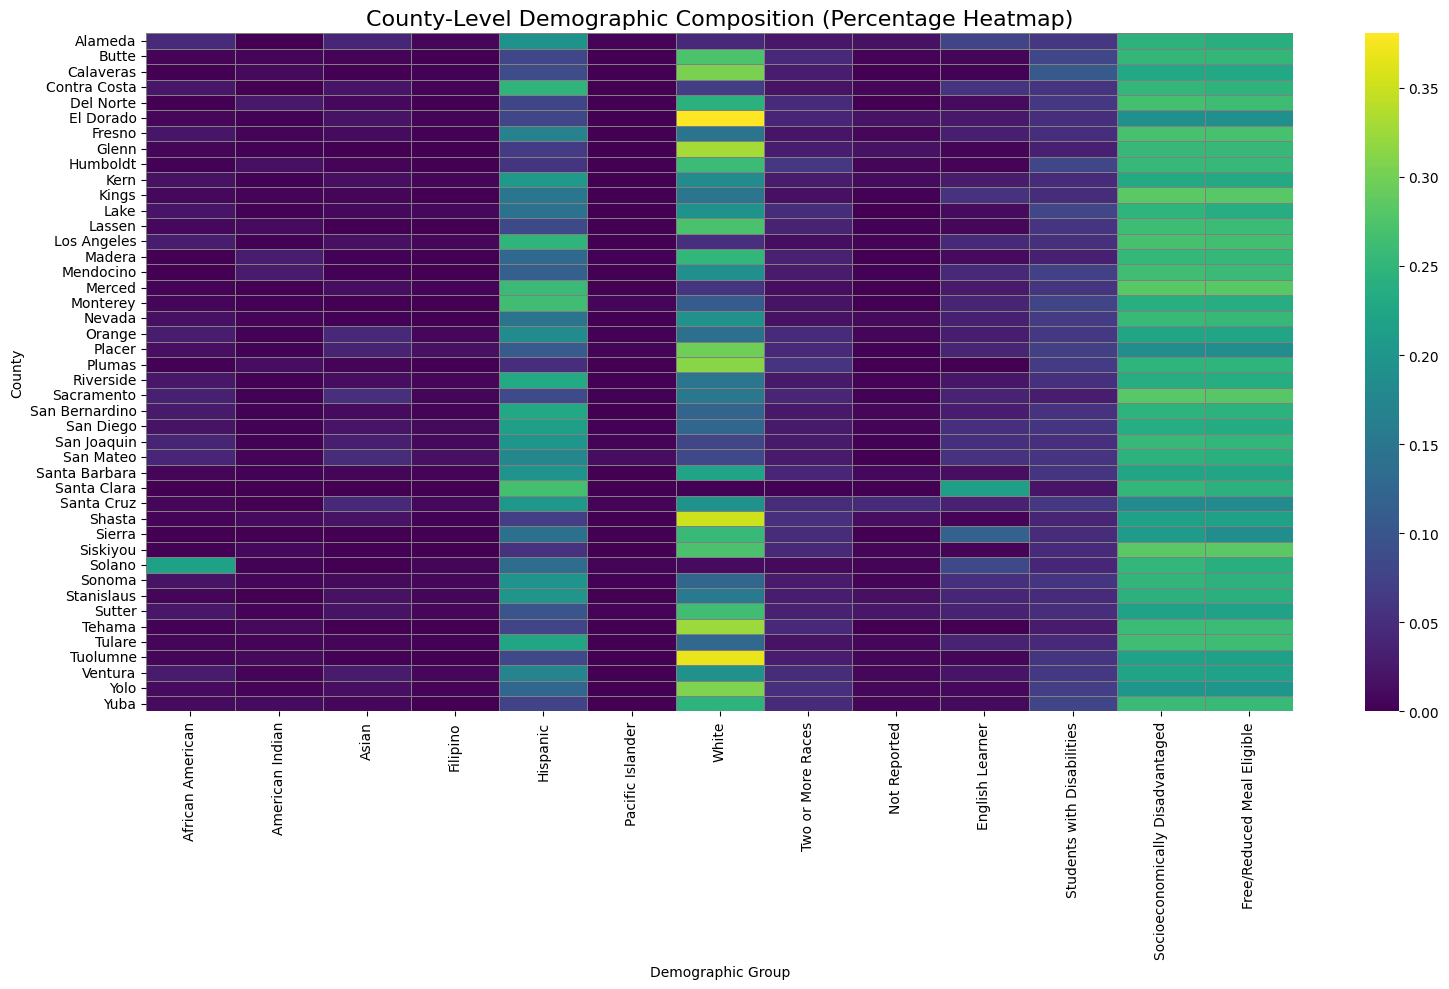

In [33]:
#Normalize by county size (percentage heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

county_demo_pct = county_demo_totals.div(
    county_demo_totals.sum(axis=1), axis=0
)

plt.figure(figsize=(16, 10))
sns.heatmap(
    county_demo_pct,
    cmap="viridis",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("County-Level Demographic Composition (Percentage Heatmap)", fontsize=16)
plt.xlabel("Demographic Group")
plt.ylabel("County")
plt.tight_layout()
plt.show()



### 🔍 County-Level Demographic Composition — Insights

This heatmap highlights the demographic diversity and socioeconomic landscape of
California’s K–12 system at the county level. Each column represents a demographic
or programmatic group, and each row represents a county, allowing for clear
comparisons across regions.

A few strong patterns emerge:

**1. Hispanic enrollment dominates statewide.**  
Most counties show high percentages of Hispanic students, especially in Southern
California and Central Valley regions. This reflects long‑standing population
trends and migration patterns.

**2. Asian enrollment is concentrated in specific counties.**  
Counties such as Santa Clara, Alameda, and San Mateo show noticeably higher Asian
representation, aligning with tech‑driven, immigrant‑rich communities.

**3. White enrollment is highest in rural and suburban counties.**  
Northern and inland counties show higher percentages of White students, consistent
with lower population density and different migration histories.

**4. Programmatic needs (EL, SWD, SED, FRPM) reveal structural inequities.**  
- **SED and FRPM** percentages are high across many counties, indicating widespread
  socioeconomic challenges.  
- **English Learner (EL)** percentages vary sharply, highlighting counties with
  large multilingual communities.  
- **Students with Disabilities (SWD)** remain relatively consistent across counties.

Overall, the heatmap shows that California’s educational landscape is shaped by
distinct regional demographic patterns. These insights are essential for
county-level planning, funding allocation, and equity-focused decision-making.